# Module_1: Alzheimer's Disease

## Team Members:
Iliya Somov : Charlotte Goodwin

## Project Title:
Does the APOE ε4 Gene Affect Amyloid and Tau Levels in the Brain?

## Project Goal:
APOE ε4 is the most common gene variant that raises the risk of Alzheimer's disease (AD). This project seeks to find out whether people with the ε4 variant have more of the proteins that build up in Alzheimer's brains, amyloid-beta (Aβ) and tau. Our questions are:

1. Do donors with APOE 3/4 have more Aβ40 than donors with APOE 3/3?
2. Are Aβ42, phosphorylated tau (pTau) and total tau also higher in APOE 3/4 donors?
3. Is there a linear relationship between pTau and Aβ42?

## Disease Background:

* **Prevalence & incidence:** About 7.4 million Americans age 65 and older have Alzheimer's dementia in 2026, which is about 1 in 9 people in that age group. Almost two-thirds of them are women [1].
* **Economic burden:** Care for people with dementia will cost about \$409 billion in the U.S. in 2026. Family members also gave about 19.6 billion hours of unpaid care in 2025 [1].
* **Risk factors (genetic, lifestyle):** The biggest risk factor is age. Having one copy of APOE ε4 raises the risk, and having two copies raises it more [1, 3]. Lifestyle factors like high blood pressure, diabetes, smoking and lack of exercise also increase risk [1].
* **Societal determinants:** Older Black Americans are about twice as likely, and older Hispanic Americans about 1.5 times as likely, to have Alzheimer's or another dementia as older White Americans. Differences in health care access and other health conditions are thought to be part of the reason [1].
* **Symptoms:** Memory loss is usually the first sign, especially forgetting recent events. Later, people get confused, have trouble with language and daily tasks, and have changes in mood and behavior. In the late stage, people need help with everything [1].
* **Diagnosis:** Doctors use memory and thinking tests (like the MMSE), a medical history and brain scans. PET scans, spinal fluid tests or newer blood tests can show whether amyloid is building up [1]. A final diagnosis can only be made by examining the brain after death [5].
* **Standard of care treatments (& reimbursement):** Drugs like donepezil and memantine help with symptoms but do not stop the disease [1]. Newer antibody drugs like lecanemab remove amyloid and slow decline in early AD. Medicare covers lecanemab only if the patient's doctor enrolls them in a registry [2].
* **Disease progression & prognosis:** Brain changes can start 20 years or more before symptoms appear [1]. After diagnosis, people 65 and older live on average 4 to 8 years, and Alzheimer's is the 5th-leading cause of death for Americans 65 and older [1].
* **Continuum of care providers:** Primary care doctors, neurologists, geriatricians, nurses, social workers, home health aides, nursing homes, hospice and unpaid family caregivers [1].
* **Biological mechanisms (anatomy, organ physiology, cell & molecular physiology):**
  * *Amyloid:* The amyloid precursor protein is cut into Aβ fragments. Aβ40 is the most common one, and Aβ42 clumps together more easily. They build up into plaques outside neurons [3].
  * *Tau:* Tau normally helps hold the neuron's structure together. When it gets too many phosphate groups (pTau), it forms tangles inside neurons.
  * *Brain damage:* Neurons die, starting in memory areas like the hippocampus.
  * *APOE:* The APOE protein carries fats in the brain. The ε4 version is worse at clearing Aβ, so Aβ builds up more [3].
* **Clinical Trials/next-gen therapies:** In 2026 there are 192 clinical trials testing 158 drugs for AD. Most try to change the disease itself, and more trials now target tau and inflammation instead of only amyloid [4].

## Data-Set:

We used data from the Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD), which is described in Gabitto et al. (2024) [5] and can be downloaded from the SEA-AD website [6].

The data consits of 84 people who donated their brains after death (51 women and 33 men, ages 65 to 102). They were part of two long-term aging studies in Seattle: the Adult Changes in Thought study and the University of Washington Alzheimer's Disease Research Center [5].

The file has one row per donor. The columns we used are:
* **APOE Genotype:** The two copies of the APOE gene each person has (for example, `3_4` means one ε3 and one ε4).
* **Sex** and **Age at Death**.
* **Overall AD neuropathological Change (ADNC):** How much Alzheimer's damage a pathologist found in the brain (Not AD, Low, Intermediate or High), based on plaques and tangles [5].
* **ABeta40, ABeta42, tTAU and pTAU:** The amount of each protein in the middle temporal gyrus, a part of the temporal lobe.

**How the data was collected:** Donors brains were removed quickly after death (about 7 hours on average) and examined by neuropathologists [5]. The protein levels were measured from brain tissue with a Luminex immunoassay, which uses beads coated with antibodies to detect each protein [6]. The units are **pg/µg**, meaning picograms of the protein per microgram of total protein in the sample.

## Data Analysis:

We started from our `patient.py` and `main17.py` code and added statistical tests and linear regression. The CSV file needs to be in the same folder as this notebook in order for the data help within to be accesed by our code. 

### Step 1: Import libraries and load the data

In [36]:
## importing the librarys needed to conduct all statistical analysis. 
import csv
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# our Patient class from patient.py
class Patient:
    ## The constructor sets up the attributes for each patient object.
    def __init__(self, donor_id, sex, apoe, p_tau, abeta40, abeta42):
        self.donor_id = donor_id
        self.sex = sex 
        self.apoe = apoe
        self.p_tau = p_tau
        self.abeta40 = abeta40
        self.abeta42 = abeta42

    ## This representer controls what prints when we print a patient.
    def __repr__(self):
        return f"Patient({self.donor_id}, Sex={self.sex}, APOE={self.apoe})"

    ## Class method to filter patients based on two attributes.
    def filter_patients(patient_list, sex_choice, apoe_choice):
        result = []
        for p in patient_list:
            if p.sex == sex_choice and p.apoe == apoe_choice:
                result.append(p)
        return result

## Naming the file so that the long file name does not need to be used every time it is needed.  
filename = "Metadata and Protein Data for Module 1 (1).csv"

# Load the csv and make a Patient object for each row (same as main17.py)
patients = []
with open(filename, "r") as file:
    reader = csv.DictReader(file)
    
    ## Looping through each row in the CSV file to create Patient objects and append them to the patients list.
    for row in reader:
        donor_id = row["Donor ID"]
        sex = row["Sex"]
        apoe = row["APOE Genotype"]
        p_tau = float(row["pTAU pg/ug"])
        abeta40 = float(row["ABeta40 pg/ug"])
        abeta42 = float(row["ABeta42 pg/ug"])
        patients.append(Patient(donor_id, sex, apoe, p_tau, abeta40, abeta42))

## Loading the file with pandas so we can use the other columns
df = pd.read_csv(filename)

## Printing the number of patients per genotype
print("Number of patients:", len(patients))
print(df["APOE Genotype"].value_counts())

Number of patients: 84
APOE Genotype
3_3    47
3_4    17
2_3    11
4_4     6
2_4     2
2_2     1
Name: count, dtype: int64


Most donors are 3/3 (47) or 3/4 (17). The other genotypes have too few people to compare on their own, so we focus on 3/3 vs 3/4.

### Step 2: Sort and filter

In [37]:
## Sorting the patients by pTau value from lowest to highest
sorted_by_ptau = sorted(patients, key=lambda p: p.p_tau)

## Printing the patient data of those with the 5 lowest pTau values 
print("5 lowest pTau:")
for p in sorted_by_ptau[:5]:
    print(p, "pTau =", round(p.p_tau, 2))

## Printing the patient data of those with the 5 highest pTau values
print("\n5 highest pTau:")
for p in sorted_by_ptau[-5:]:
    print(p, "pTau =", round(p.p_tau, 2))

# Filtering, counting, and printing the number of female patients with APOE 3_3
filtered_group = Patient.filter_patients(patients, "Female", "3_3")
print("\nNumber of female APOE 3_3 patients:", len(filtered_group))

5 lowest pTau:
Patient(H20.33.036, Sex=Female, APOE=2_3) pTau = 1.28
Patient(H21.33.021, Sex=Male, APOE=3_3) pTau = 1.32
Patient(H20.33.005, Sex=Female, APOE=2_3) pTau = 1.33
Patient(H21.33.014, Sex=Male, APOE=2_3) pTau = 1.6
Patient(H21.33.013, Sex=Female, APOE=3_4) pTau = 1.63

5 highest pTau:
Patient(H20.33.011, Sex=Female, APOE=3_4) pTau = 8.54
Patient(H21.33.045, Sex=Female, APOE=3_4) pTau = 11.49
Patient(H20.33.032, Sex=Male, APOE=3_3) pTau = 12.47
Patient(H20.33.026, Sex=Female, APOE=4_4) pTau = 12.57
Patient(H20.33.046, Sex=Male, APOE=3_3) pTau = 15.92

Number of female APOE 3_3 patients: 28


It is worth noting that 3 of the 5 donors with the highest pTau carry ε4, compared with only 1 of the 5 lowest.

### Step 3: Question 1: Aβ40 in APOE 3_3 vs 3_4 (bar graph)

APOE 3_3: n = 47  mean = 9.14  median = 1.63
APOE 3_4: n = 17  mean = 36.74  median = 17.22


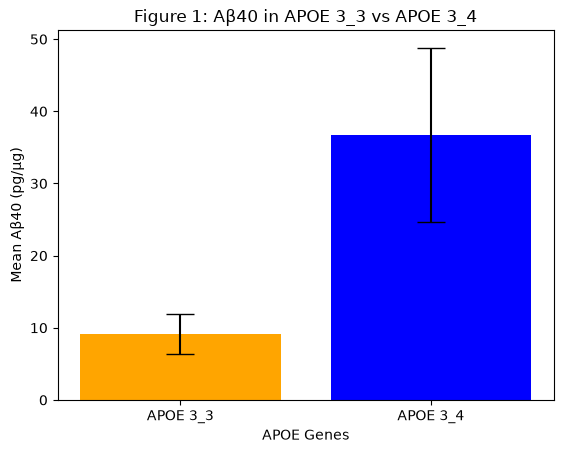

In [38]:
# Collecting the Aβ40 values for each group
abeta40_33 = [p.abeta40 for p in patients if p.apoe == "3_3"]
abeta40_34 = [p.abeta40 for p in patients if p.apoe == "3_4"]

# Calculating the mean, standard error, and median for each group
mean_33 = statistics.mean(abeta40_33)
mean_34 = statistics.mean(abeta40_34)
se_33 = statistics.stdev(abeta40_33) / np.sqrt(len(abeta40_33))
se_34 = statistics.stdev(abeta40_34) / np.sqrt(len(abeta40_34))

# Prinintg the number of patients, mean, and median per group
print("APOE 3_3: n =", len(abeta40_33), " mean =", round(mean_33, 2), " median =", round(statistics.median(abeta40_33), 2))
print("APOE 3_4: n =", len(abeta40_34), " mean =", round(mean_34, 2), " median =", round(statistics.median(abeta40_34), 2))

# Creating the bar graph of the means with standard error bars
plt.bar(["APOE 3_3", "APOE 3_4"], [mean_33, mean_34], yerr=[se_33, se_34], capsize=10, color=["orange", "blue"])
plt.ylabel("Mean Aβ40 (pg/µg)")
plt.xlabel("APOE Genes")
plt.title("Figure 1: Aβ40 in APOE 3_3 vs APOE 3_4")
plt.show()

Before picking a test, we checked whether the data is normally distributed with the Shapiro-Wilk test. If p < 0.05, the data is not normal, and a t-test would not be a good choice.

In [39]:
# Shapiro-Wilk test for normality and print results
print("Shapiro-Wilk p (3_3):", stats.shapiro(abeta40_33).pvalue)
print("Shapiro-Wilk p (3_4):", stats.shapiro(abeta40_34).pvalue)

# The data is not normal, so we apply and print the results of the the Mann-Whitney U test 
result = stats.mannwhitneyu(abeta40_33, abeta40_34)
print("\nMann-Whitney U p-value:", result.pvalue)

Shapiro-Wilk p (3_3): 4.193159234437583e-11
Shapiro-Wilk p (3_4): 0.0001890069774494714

Mann-Whitney U p-value: 0.000353966046848835


Neither group is normally distributed (both Shapiro-Wilk p < 0.001), so we used the **Mann-Whitney U test**, which does not assume normal data. APOE 3/4 donors had much more Aβ40 than 3/3 donors:
* **mean:** 36.7 vs 9.1 pg/µg;
* **median:** 17.2 vs 1.6 pg/µg;
* **Mann-Whitney p = 0.0004**, so the difference is significant.

The low p value indicates that the 2 groups (3_4 and 3_3) are significantly diffrent from one another. This just gives us a general indication that the Aβ40 values in 3_3 tend to be significantly lower than the Aβ40 in 3_4. 

### Step 4: Question 2: other proteins
We ran the same Mann-Whitney test on the other three proteins; ABeta42, pTAU, and tTAU. We wanted to see if there was significant variance in the mean concentration of these other proteins between the 2 gene combinations. 

In [40]:
# Creating new dataframes 
group_33 = df[df["APOE Genotype"] == "3_3"]
group_34 = df[df["APOE Genotype"] == "3_4"]

# Comparing each protein between the two groups
for protein in ["ABeta42 pg/ug", "pTAU pg/ug", "tTAU pg/ug"]:
    median_33 = group_33[protein].median()
    median_34 = group_34[protein].median()
    p_value = stats.mannwhitneyu(group_33[protein], group_34[protein]).pvalue
    print(protein, "| median 3_3 =", round(median_33, 2), "| median 3_4 =", round(median_34, 2),
          "| p =", round(p_value, 4))

ABeta42 pg/ug | median 3_3 = 24.64 | median 3_4 = 68.37 | p = 0.0035
pTAU pg/ug | median 3_3 = 3.37 | median 3_4 = 5.11 | p = 0.0387
tTAU pg/ug | median 3_3 = 302.23 | median 3_4 = 318.53 | p = 0.8672


* **Aβ42:** clearly higher in 3/4 donors (68.4 vs 24.6 pg/µg, p = 0.0035).
* **pTau:** a little higher (5.1 vs 3.4 pg/µg, p = 0.039).
* **Total tau:** no difference (p = 0.87).

So ε4 seems to affect amyloid the most, has a smaller effect on pTau, and does not change the total amount of tau.

### Step 5: Question 3: pTau vs Aβ42 (scatter plot and linear regression)

Raw data: slope = 8.28  R^2 = 0.018  p = 0.226


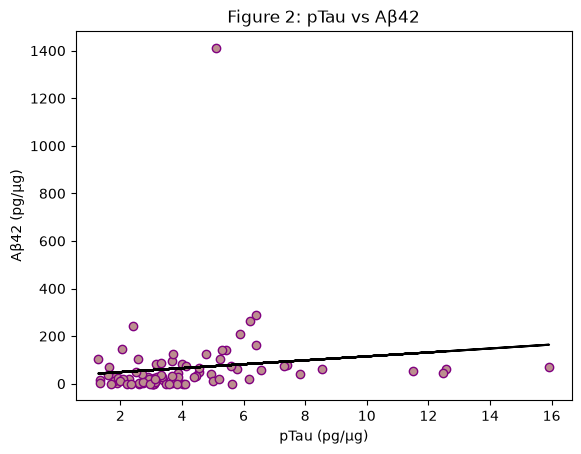

In [41]:
# Gathering pTau and Aβ42 for every patient (same as main17.py)
p_tau_vals = np.array([p.p_tau for p in patients])
abeta42_vals = np.array([p.abeta42 for p in patients])

# Calculating the linear regression on the raw values
reg = stats.linregress(p_tau_vals, abeta42_vals)
print("Raw data: slope =", round(reg.slope, 2), " R^2 =", round(reg.rvalue**2, 3), " p =", round(reg.pvalue, 3))

# Creating the scatter plot with the regression line
plt.scatter(p_tau_vals, abeta42_vals, color = "rosybrown", marker = 'o', edgecolors = 'purple')
plt.plot(p_tau_vals, reg.slope * p_tau_vals + reg.intercept, color="black")
plt.xlabel("pTau (pg/µg)")
plt.ylabel("Aβ42 (pg/µg)")
plt.title("Figure 2: pTau vs Aβ42")
plt.show()

The raw regression is not significant (R² = 0.02, p = 0.23). Most points are bunched near the bottom, and one donor with a very high Aβ42 (about 1,400 pg/µg) pulls on the line. Because the values cover such a big range, we took the log10 of both variables and ran the regression again. Taking the log10 of the variables compresses the large range of data points into a much more manageable scale. 

Log data: slope = 1.45  R^2 = 0.103  p = 0.0028


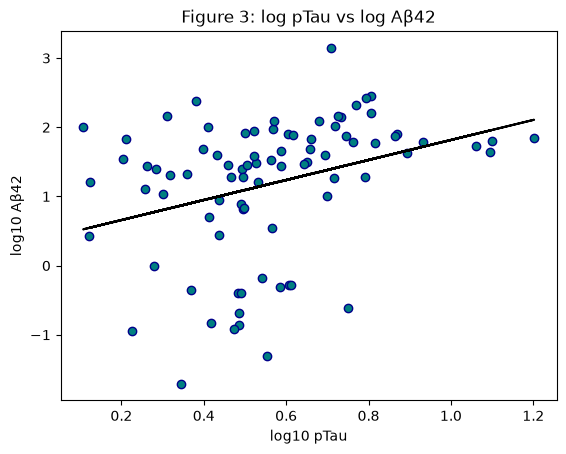

In [42]:
# Taking the log10 of both variables to spread out the data
log_ptau = np.log10(p_tau_vals)
log_abeta42 = np.log10(abeta42_vals)

# Calculating the linear regression on the log values
log_reg = stats.linregress(log_ptau, log_abeta42)
print("Log data: slope =", round(log_reg.slope, 2), " R^2 =", round(log_reg.rvalue**2, 3), " p =", round(log_reg.pvalue, 4))

# Creating the second scatter plot 
plt.scatter(log_ptau, log_abeta42, color = "teal", marker = 'o', edgecolors = 'darkblue', )
plt.plot(log_ptau, log_reg.slope * log_ptau + log_reg.intercept, color="black")
plt.xlabel("log10 pTau")
plt.ylabel("log10 Aβ42")
plt.title("Figure 3: log pTau vs log Aβ42")
plt.show()

After the log transform, the relationship is positive and significant (slope = 1.45, p = 0.003). However, R² is only 0.10, so pTau explains only about 10% of the variation in Aβ42. The two proteins do go up together, but the relationship is weak.

## Verify and validate your analysis:

**Verify:**
* *Data check:* we compared our data with the numbers reported in the published paper [5]. The code below shows that we have the same 84 donors, 51 women and 33 men, and the same ADNC counts (9 Not AD, 12 Low, 21 Intermediate, 42 High).
* *Second test:* we also ran a t-test on the log10 Aβ40 values. It gave the same answer as the Mann-Whitney test.

Donors: 84
Sex
Female    51
Male      33
Name: count, dtype: int64
Overall AD neuropathological Change
High            42
Intermediate    21
Low             12
Not AD           9
Name: count, dtype: int64

t-test on log10 Aβ40, p = 0.0016871833518879208


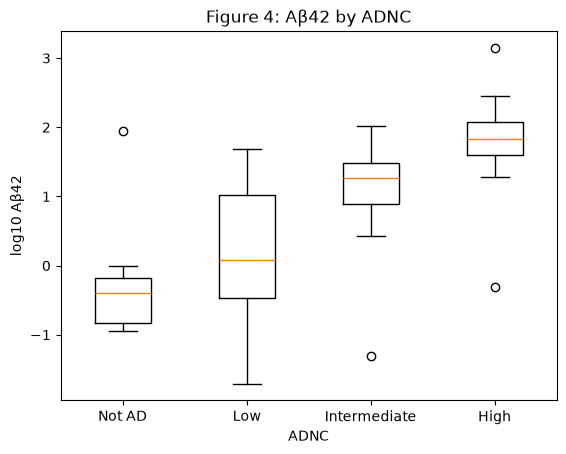

Overall AD neuropathological Change
High            20
Intermediate     5
Low              0
Not AD           0
Name: e4_carrier, dtype: int64


In [43]:
# Checking our data against the numbers reported in Gabitto et al. (2024)
print("Donors:", len(df))
print(df["Sex"].value_counts())
print(df["Overall AD neuropathological Change"].value_counts())

# Checking the Aβ40 result with a t-test on log10 values
print("\nt-test on log10 Aβ40, p =", stats.ttest_ind(np.log10(abeta40_33), np.log10(abeta40_34)).pvalue)

# Aβ42 for each ADNC group
adnc_levels = ["Not AD", "Low", "Intermediate", "High"]
adnc_groups = []
for level in adnc_levels:
    values = df[df["Overall AD neuropathological Change"] == level]["ABeta42 pg/ug"]
    adnc_groups.append(np.log10(values))

## Creating a Boxplot to visually display results 
plt.boxplot(adnc_groups)
plt.xticks([1, 2, 3, 4], adnc_levels)
plt.xlabel("ADNC")
plt.ylabel("log10 Aβ42")
plt.title("Figure 4: Aβ42 by ADNC")
plt.show()

# Fining how many ε4 carriers are in each ADNC group (the paper reports 20 of 42 High and 5 of 21 Intermediate)
df["e4_carrier"] = df["APOE Genotype"].str.contains("4")
print(df.groupby("Overall AD neuropathological Change")["e4_carrier"].sum())

Our data matches the paper, the t-test on log values agree (p = 0.002), and Aβ42 rises steadily with ADNC (Spearman ρ = 0.71, p < 0.001).

**Validate:**
* *The SEA-AD paper:* Gabitto et al. found that ε4 carriers made up 20 of the 42 donors with High ADNC and none of the Low or Not AD donors [5]. Our code shows the same counts. This fits our result that ε4 carriers have more amyloid.
* *Other research:* A review by Liu et al. explains that the ApoE4 protein is worse at clearing Aβ from the brain, so ε4 carriers build up more amyloid plaques [3]. This matches what we found.

**Possible sources of error:**
* *Skewed data:* Most donors have low protein values and a few have very high ones, which affects means and regression lines.
* *Very small values:* Some Aβ40 values are tiny (around 0.0001 pg/µg) and may be below what the test can measure accurately.
* *Small group:* The 3/4 group has only 17 people.
* *Many tests:* We ran several tests, so the borderline pTau result (p = 0.039) could be a false positive.

## Conclusions and Ethical Implications:

**Conclusions:**
* *Main result:* Donors with APOE 3/4 had about 10 times more Aβ40 (median) than 3/3 donors (p = 0.0004).
* *Other proteins:* They also had about 3 times more Aβ42. pTau was only slightly higher, and total tau was the same.
* *pTau and Aβ42:* On a log scale they had a weak positive relationship (R² = 0.10).
* *Overall:* This supports the idea that ε4 leads to more amyloid, and that amyloid is linked to tau pathology.

**Trends and anomalies:**
* *Overlap:* Some 3/3 donors had high Aβ40 and one 3/4 donor had very little, so ε4 raises the chance of amyloid buildup but does not guarantee it.
* *Unusual donor:* The donor with the highest total tau (about 7,000 pg/µg, over 20 times the median) had no Alzheimer's pathology. This could be a measurement error or a different disease.

**Recommendation:**
* *For doctors:* Consider APOE testing, with genetic counseling, before starting anti-amyloid drugs. In our data ε4 carriers had the most amyloid, but ε4 carriers also have a higher risk of the brain swelling side effect (ARIA), and the FDA encourages testing before treatment [2].
* *For researchers:* Studies of amyloid in brain tissue should report APOE ε4 status, since it makes such a big difference.

**Ethical implications:**
* *Privacy:* APOE results are genetic information and should be kept private, because they could be misused (for example by insurance companies) and they also say something about family members.
* *Risk is not destiny:* Having ε4 does not mean someone will definitely get Alzheimer's, so results should be explained carefully to avoid unnecessary fear.
* *Diversity:* 81 of the 84 donors are White and none are Black. The paper says the cohort is almost entirely of European descent [5], so our results may not apply to other groups.

## Limitations and Future Work:

**Limitations:**
* *Small groups:* There are only 17 APOE 3/4 donors and 6 APOE 4/4 donors.
* *One time point:* The brains were studied after death, so we cannot tell what happened first or prove that ε4 causes the protein changes.
* *No other factors:* We did not control for things like age or sex.
* *One brain region:* The proteins were only measured in one part of the brain.

**Future Work:**
* Compare 0, 1 and 2 copies of ε4, and use regression to control for age and sex.
* See whether protein levels are related to memory test scores such as the MMSE.
* Repeat the analysis with a larger and more diverse group of donors.

## NOTES FROM YOUR TEAM:
*This is where our team is taking notes and recording activity.*

* Wrote `patient.py` and `main17.py` to load, sort and filter the data and make the bar graph and scatter plot.
* Found that the data was not normal, so we switched from a t-test to Mann-Whitney U.
* Added linear regression and used log10 because the raw data was very skewed.
* Added borders around points on scatter plots to points are more distinguisable even in clumps. 
* Checked our data against the published paper.

**AI use:** We used Claude (Anthropic) to help us understand how to use and apply the statistical tests that we needed for this dataset, especially since it was not normally distributed. We also used Claude to help double check our code and provide us with some pseudocode to get the ball rolling. We also used it to make our formatting a whole lot nicer i.e bolded letters, italics.

## QUESTIONS FOR YOUR TA:
*These are questions we have for our TA.*

1. Is Mann-Whitney U the right test for our data, or should we use a t-test on the log values?
2. Should we remove the very small Aβ40 values that might be below what the test can detect?
3. What is the best outliar test and removal method for this dataset? Is the log 10 application the most effective or is there something else that should be done?

## References
1. Alzheimer's Association. 2026 Alzheimer's Disease Facts and Figures. https://www.alz.org/alzheimers-dementia/facts-figures
2. Alzheimer's Association. Lecanemab (Leqembi). https://www.alz.org/alzheimers-dementia/treatments/lecanemab-leqembi
3. Liu CC, Kanekiyo T, Xu H, Bu G. Apolipoprotein E and Alzheimer disease: risk, mechanisms and therapy. *Nature Reviews Neurology* 9, 106–118 (2013).
4. Cummings JL, et al. Alzheimer's disease drug development pipeline: 2026. *Alzheimer's & Dementia: TRCI* (2026). https://doi.org/10.1002/trc2.70251
5. Gabitto MI, et al. Integrated multimodal cell atlas of Alzheimer's disease. *Nature Neuroscience* 27, 2366–2383 (2024). https://doi.org/10.1038/s41593-024-01774-5
6. Allen Institute for Brain Science. SEA-AD Documentation, Data, and Downloads. https://brain-map.org/consortia/sea-ad/our-data